## Variable Descriptions

#### Pregnancies
information about the number of pregnancy female had till date
#### Glucose
glucose level of patient generally higher glucose level shoes the chances of sugar
#### BloodPressure
Blood pressure data of the patient
#### SkinThickness
Skin thickness of patient
#### Insulin
Insulin level of patient
#### BMI
The full form of BMI is Body Mass Index. It is a method of measuring through which individuals are classified into the  following categories: obese, overweight, normal weight and underweight.
#### Diabetes pedigree function 
The Diabetes Pedigree Function, pedi, provides some data on diabetes mellitus history in relatives and the genetic relationship of those relatives to the patient. This measure of genetic influence give us an idea of the hereditary risk one might have with the onset of diabetes mellitus
#### Age
Age of patient
#### Outcome
0 shows that patient doesn't have diabetes
1 shows patient have diabetes.

In [39]:
#Lazimli kitabxanalari elave edirem
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns   
import numpy as np
import scipy.stats as stats
from statsmodels.stats.power import TTestIndPower, TTestPower, GofChisquarePower
import statsmodels.stats.api as sms
from scipy.stats import ttest_1samp, shapiro, levene, ttest_ind, mannwhitneyu,pearsonr, spearmanr, kendalltau, f_oneway, kruskal
from statsmodels.stats.proportion import proportions_ztest

In [40]:
#datasetimi oxuduram ve ilk 5 setiri gosterirem
df = pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [41]:
#boyukluyune baxiram 
df.shape

(768, 9)

In [42]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [43]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [44]:
# Nan 
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [45]:
#eyni 
df.duplicated().sum()

np.int64(0)

In [46]:
#null
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

For better view I make all columns uppercase:

In [47]:
df.columns= [col.upper() for col in df.columns]
df.columns

Index(['PREGNANCIES', 'GLUCOSE', 'BLOODPRESSURE', 'SKINTHICKNESS', 'INSULIN',
       'BMI', 'DIABETESPEDIGREEFUNCTION', 'AGE', 'OUTCOME'],
      dtype='object')

Plots histograms for all numerical columns in the DataFrame.

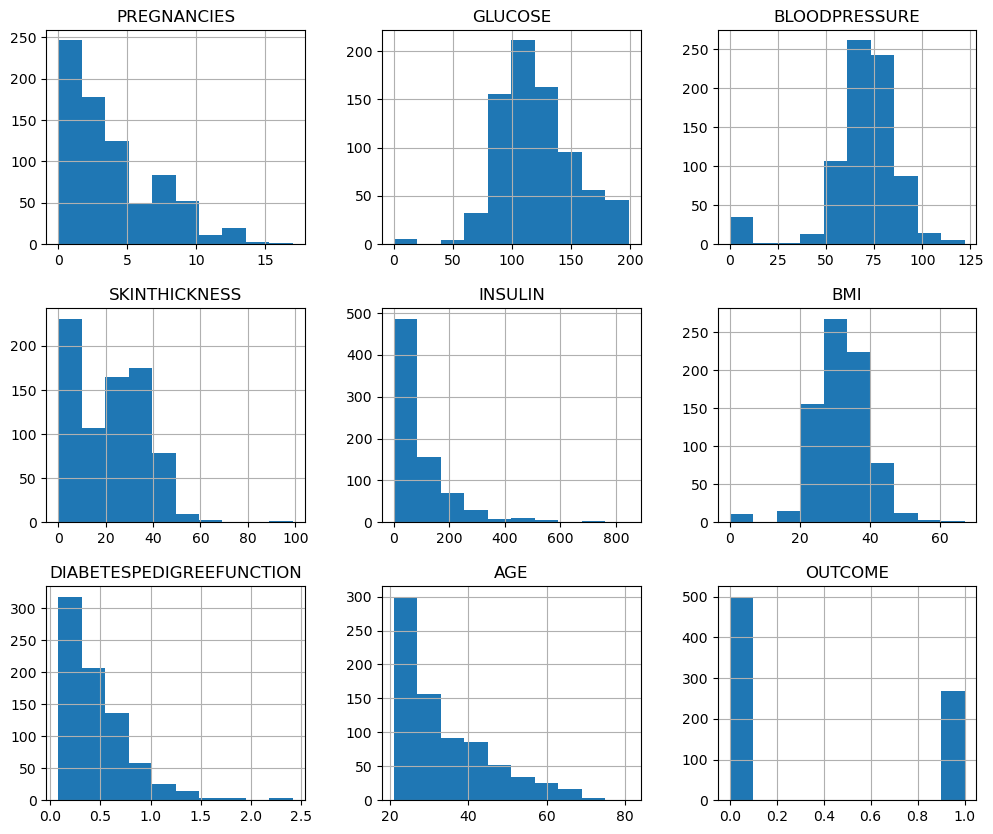

In [48]:
df.hist(figsize=(12,10))
plt.show()

Generates pairwise plots between all numerical columns in the dataset

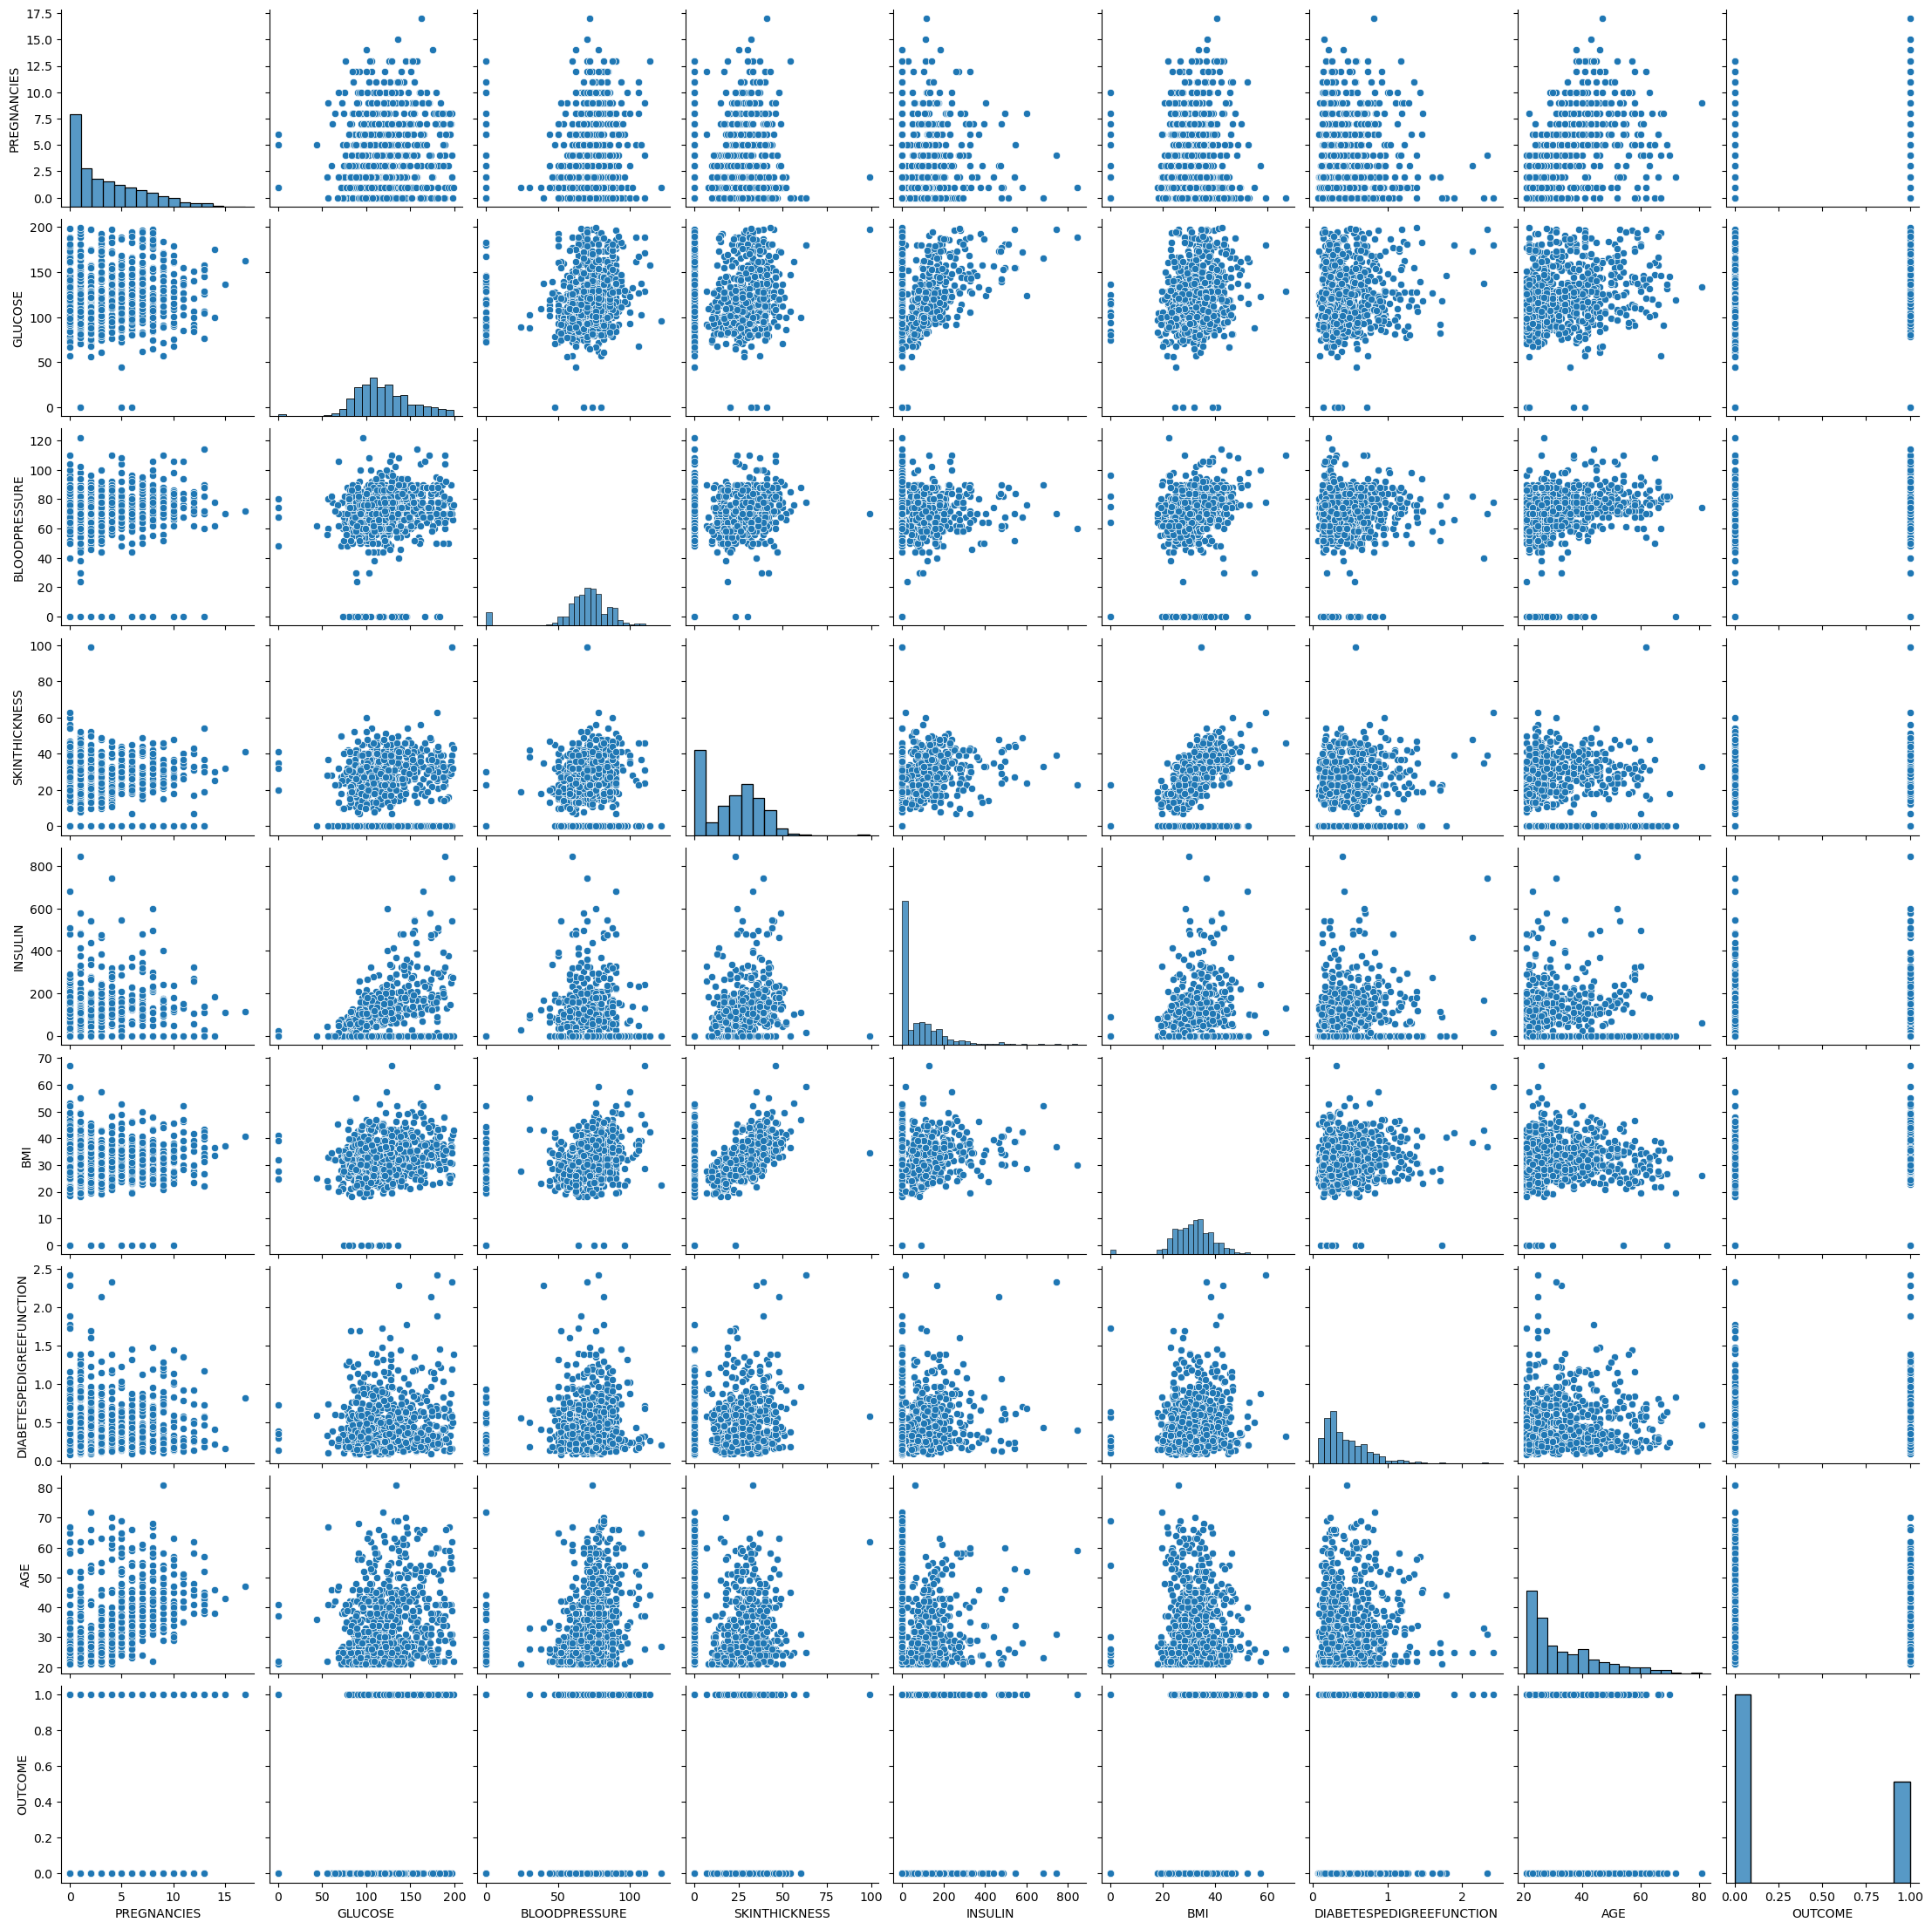

In [49]:
# butun elaqeleri bir anda gormek ucun:
sns.pairplot(df)
plt.show()

Groups the dataset by OUTCOME and calculates the mean AGE for each group.

In [50]:
#OUTCOME qruplarına göre AGE orta deyerlerini hesablayır
df.groupby("OUTCOME").agg({"AGE": "mean"})

,AGE
OUTCOME,
0,31.190000
1,37.067164


In [51]:
#Shapiro-Wilk testi ile her qrup üçün normal paylanma yoxlanilir 1 diabet xestesi demekdir 0 saglam olanlar
test_stat, pvalue = shapiro(df.loc[df["OUTCOME"] == 1, "AGE"].dropna())

In [52]:
print('Test Stat = %.4f, p-value = %.4f' % (test_stat, pvalue))

Test Stat = 0.9546, p-value = 0.0000


In [53]:
test_stat, pvalue = shapiro(df.loc[df["OUTCOME"] == 0, "AGE"].dropna())

In [54]:
print('Test Stat = %.4f, p-value = %.4f' % (test_stat, pvalue))

Test Stat = 0.8012, p-value = 0.0000


In [55]:
#normal paylanma olmadigina gore Mann-Whitney U testi edirem
test_stat, pvalue = mannwhitneyu(df.loc[df["OUTCOME"] == 1, "AGE"].dropna(),
                                 df.loc[df["OUTCOME"] == 0, "AGE"].dropna())

In [56]:
print('Test Stat = %.4f, p-value = %.4f' % (test_stat, pvalue))

Test Stat = 92050.0000, p-value = 0.0000


In [57]:
group1 = df[df['OUTCOME'] == 0]['GLUCOSE']
group2 = df[df['OUTCOME'] == 1]['GLUCOSE']

stat, p = stats.levene(group1, group2)
print(f"Levene: Statistics={stat:.3f}, p-value={p:.3f}")

Levene: Statistics=20.945, p-value=0.000


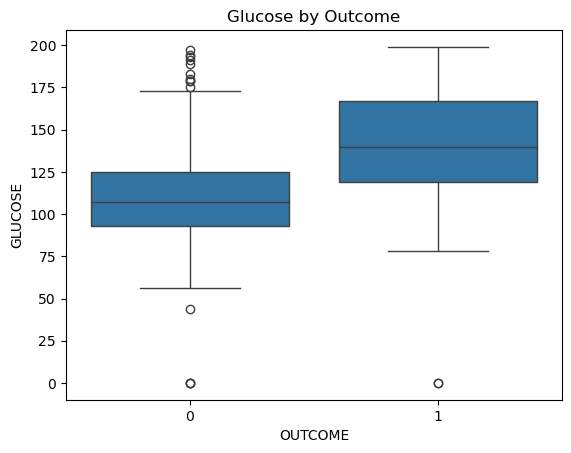

In [58]:
sns.boxplot(x='OUTCOME', y='GLUCOSE', data=df)
plt.title("Glucose by Outcome")
plt.show()

this tests normality of each variable using Shapiro-Wilk test:

In [59]:
test_cols = ['PREGNANCIES', 'GLUCOSE', 'BLOODPRESSURE', 'SKINTHICKNESS', 'INSULIN',
             'BMI', 'DIABETESPEDIGREEFUNCTION', 'AGE']

print(f"{'VARIABLE':<25} | {'GROUP':<12} | {'STATISTIC (W)':<15} | {'P-VALUE':<10} | {'RESULT'}")
print("-" * 85)

for col in test_cols:
    for outcome_val in [0, 1]:
        # Filter data (e.g., OUTCOME = 0 and selected column)
        group_data = df[df['OUTCOME'] == outcome_val][col].dropna()
        
        stat, p = stats.shapiro(group_data)
        
        group_name = "Healthy" if outcome_val == 0 else "Diabetic"
        decision = "Normal" if p > 0.05 else "NOT Normal"
        
        print(f"{col:<25} | {group_name:<12} | {stat:<15.4f} | {p:<10.5f} | {decision}")
    
    print("-" * 85)

VARIABLE                  | GROUP        | STATISTIC (W)   | P-VALUE    | RESULT
-------------------------------------------------------------------------------------
PREGNANCIES               | Healthy      | 0.8793          | 0.00000    | NOT Normal
PREGNANCIES               | Diabetic     | 0.9432          | 0.00000    | NOT Normal
-------------------------------------------------------------------------------------
GLUCOSE                   | Healthy      | 0.9679          | 0.00000    | NOT Normal
GLUCOSE                   | Diabetic     | 0.9588          | 0.00000    | NOT Normal
-------------------------------------------------------------------------------------
BLOODPRESSURE             | Healthy      | 0.8316          | 0.00000    | NOT Normal
BLOODPRESSURE             | Diabetic     | 0.7844          | 0.00000    | NOT Normal
-------------------------------------------------------------------------------------
SKINTHICKNESS             | Healthy      | 0.9193          | 0.00

Levene test checks if variances between groups are equal :
p > 0.05 → Equal variance
p < 0.05 → Not equal

In [60]:
target_col = 'OUTCOME'

test_cols = ['PREGNANCIES', 'GLUCOSE', 'BLOODPRESSURE', 'SKINTHICKNESS', 'INSULIN',
             'BMI', 'DIABETESPEDIGREEFUNCTION', 'AGE']

print("--- Variance Equality Analysis (Levene's Test) ---")
print(f"{'VARIABLE':<15} | {'STATISTIC (W)':<15} | {'P-VALUE':<10} | {'VARIANCE STATUS'}")
print("-" * 75)

for col in test_cols:
    # Split groups
    group_0 = df[df[target_col] == 0][col].dropna()
    group_1 = df[df[target_col] == 1][col].dropna()
    
    # Run Levene Test
    stat, p = stats.levene(group_0, group_1)
    
    # Decision
    result = "Equal (Homogeneous)" if p > 0.05 else "Not Equal (Heterogeneous)"
    
    # Print results
    print(f"{col:<15} | {stat:<15.4f} | {p:<10.5f} | {result}")

print("-" * 75)

--- Variance Equality Analysis (Levene's Test) ---
VARIABLE        | STATISTIC (W)   | P-VALUE    | VARIANCE STATUS
---------------------------------------------------------------------------
PREGNANCIES     | 22.7472         | 0.00000    | Not Equal (Heterogeneous)
GLUCOSE         | 20.9453         | 0.00001    | Not Equal (Heterogeneous)
BLOODPRESSURE   | 1.7120          | 0.19112    | Equal (Homogeneous)
SKINTHICKNESS   | 10.9587         | 0.00098    | Not Equal (Heterogeneous)
INSULIN         | 17.8162         | 0.00003    | Not Equal (Heterogeneous)
BMI             | 2.6202          | 0.10592    | Equal (Homogeneous)
DIABETESPEDIGREEFUNCTION | 11.7976         | 0.00062    | Not Equal (Heterogeneous)
AGE             | 2.2252          | 0.13619    | Equal (Homogeneous)
---------------------------------------------------------------------------


Mann–Whitney U Test compares two independent groups
Used when data is not normally distributed
p < 0.05 → Significant difference
p > 0.05 → No significant difference

In [61]:
test_cols = ['PREGNANCIES', 'GLUCOSE', 'BLOODPRESSURE', 'SKINTHICKNESS', 'INSULIN',
             'BMI', 'DIABETESPEDIGREEFUNCTION', 'AGE']

target_col = 'OUTCOME'

print(f"{'VARIABLE':<25} | {'U-STATISTIC':<15} | {'P-VALUE':<10} | {'RESULT'}")
print("-" * 75)

for col in test_cols:
    # Split groups
    g0 = df[df[target_col] == 0][col].dropna()
    g1 = df[df[target_col] == 1][col].dropna()
    
    # Mann-Whitney U Test
    u_stat, p_val = stats.mannwhitneyu(g0, g1)
    
    # Decision
    result = "Significant Difference" if p_val < 0.05 else "No Significant Difference"
    
    print(f"{col:<25} | {u_stat:<15.1f} | {p_val:<10.5f} | {result}")

VARIABLE                  | U-STATISTIC     | P-VALUE    | RESULT
---------------------------------------------------------------------------
PREGNANCIES               | 50985.0         | 0.00000    | Significant Difference
GLUCOSE                   | 28390.5         | 0.00000    | Significant Difference
BLOODPRESSURE             | 55414.5         | 0.00008    | Significant Difference
SKINTHICKNESS             | 59814.0         | 0.01296    | Significant Difference
INSULIN                   | 61926.5         | 0.06566    | No Significant Difference
BMI                       | 41866.0         | 0.00000    | Significant Difference
DIABETESPEDIGREEFUNCTION  | 52769.0         | 0.00000    | Significant Difference
AGE                       | 41950.0         | 0.00000    | Significant Difference


Insulin (INSULIN): Interestingly, the p-value is $p = 0.065$. If we take the significance level as $0.05$, there is no statistically significant difference between the groups.


In [62]:
#Glucose deyerinin orta qiymetini std ve NaN olmayanin hesablayiram
glucose_mean = df["GLUCOSE"].mean()
glucose_std = df["GLUCOSE"].std(ddof=1)
glucose_n = df["GLUCOSE"].count()
# 95% etibarliqini t-distribution ile hasablayiriq
glucose_ci = stats.t.interval(
    confidence=0.95,
    df=glucose_n - 1,
    loc=glucose_mean,
    scale=glucose_std / np.sqrt(glucose_n)
)
#orta deyeri ve etibarliq intervalini cap edirik
print(f"Mean Glucose: {glucose_mean:.2f}")
print(f"95% CI for Mean Glucose: {glucose_ci}")

Mean Glucose: 120.89
95% CI for Mean Glucose: (np.float64(118.62972245094552), np.float64(123.15934004905448))


In [63]:
mean_glucose = df["GLUCOSE"].mean() #burda tekrar olsa da valiablelar deyisik dusmesin deye deyisdirdim
std_glucose = df["GLUCOSE"].std()
n_glucose = df["GLUCOSE"].count()
#95% etibarliliq ucun margin error hesablanir
margin_error = stats.t.ppf(0.975, df=n_glucose-1) * (std_glucose / np.sqrt(n_glucose))
#limitleri yeni serhedleri
lower = mean_glucose - margin_error
upper = mean_glucose + margin_error

print(f"Mean Glucose: {mean_glucose:.3f}") # variable re inh
print(f"95% Confidence Interval: ({lower:.3f}, {upper:.3f})")
#iki qrup arasinda ferqi analiz edirik
mean1 = group1.mean()
mean2 = group2.mean()

std1 = group1.std()
std2 = group2.std()

n1 = group1.count()
n2 = group2.count()

diff = mean1 - mean2

se = np.sqrt((std1**2 / n1) + (std2**2 / n2))

ci_low = diff - stats.t.ppf(0.975, df=min(n1, n2)-1) * se
ci_high = diff + stats.t.ppf(0.975, df=min(n1, n2)-1) * se

print(f"Mean Difference (Outcome0 - Outcome1): {diff:.3f}")
print(f"95% Confidence Interval: ({ci_low:.3f}, {ci_high:.3f})")

Mean Glucose: 120.895
95% Confidence Interval: (118.630, 123.159)
Mean Difference (Outcome0 - Outcome1): -31.277
95% Confidence Interval: (-35.756, -26.799)


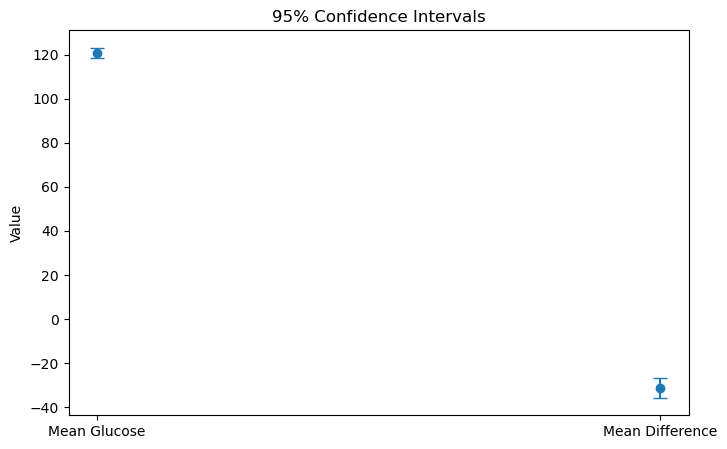

In [64]:
labels = ["Mean Glucose", "Mean Difference"]
means = [mean_glucose, diff]
errors = [margin_error, (ci_high - diff)]

plt.figure(figsize=(8,5))
plt.errorbar(labels, means, yerr=errors, fmt='o', capsize=5)
plt.title("95% Confidence Intervals")
plt.ylabel("Value")
plt.show()

In [65]:
bmi_mean = df["BMI"].mean()
bmi_std = df["BMI"].std(ddof=1)
bmi_n = df["BMI"].count()

bmi_ci = stats.t.interval(
    confidence=0.95,
    df=bmi_n - 1,
    loc=bmi_mean,
    scale=bmi_std / np.sqrt(bmi_n)
)

print(f"BMI: {bmi_mean:.2f}")
print(f"95% CI for Mean BMI: {bmi_ci}")

BMI: 31.99
95% CI for Mean BMI: (np.float64(31.434096628184115), np.float64(32.55105962181588))


For the another parametre

In [66]:
mean_bmi = df["BMI"].mean()
std_bmi = df["BMI"].std()
n_bmi = df["BMI"].count()

margin_error = stats.t.ppf(0.975, df=n_bmi-1) * (std_bmi / np.sqrt(n_bmi))

lower = mean_bmi - margin_error
upper = mean_bmi + margin_error

print(f"Mean BMI: {mean_bmi:.3f}")
print(f"95% Confidence Interval: ({lower:.3f}, {upper:.3f})")

mean1 = group1.mean()
mean2 = group2.mean()

std1 = group1.std()
std2 = group2.std()

n1 = group1.count()
n2 = group2.count()

diff = mean1 - mean2

se = np.sqrt((std1**2 / n1) + (std2**2 / n2))

ci_low = diff - stats.t.ppf(0.975, df=min(n1, n2)-1) * se
ci_high = diff + stats.t.ppf(0.975, df=min(n1, n2)-1) * se

print(f"Mean Difference (Outcome0 - Outcome1): {diff:.3f}")
print(f"95% Confidence Interval: ({ci_low:.3f}, {ci_high:.3f})")

Mean BMI: 31.993
95% Confidence Interval: (31.434, 32.551)
Mean Difference (Outcome0 - Outcome1): -31.277
95% Confidence Interval: (-35.756, -26.799)


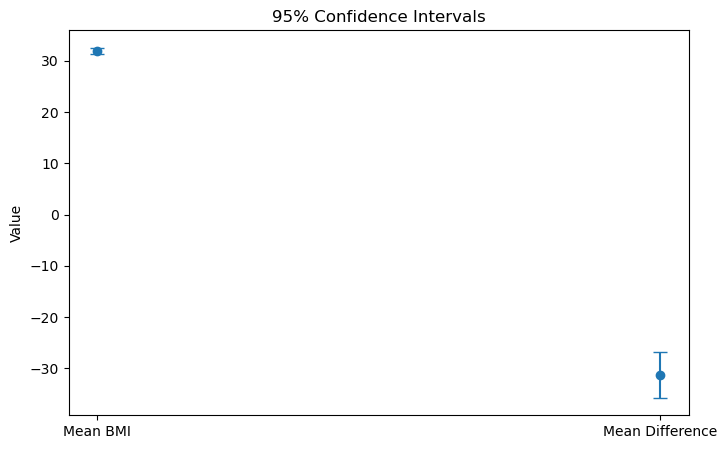

In [67]:
labels = ["Mean BMI", "Mean Difference"]
means = [mean_bmi, diff]
errors = [margin_error, (ci_high - diff)]

plt.figure(figsize=(8,5))
plt.errorbar(labels, means, yerr=errors, fmt='o', capsize=5)
plt.title("95% Confidence Intervals")
plt.ylabel("Value")
plt.show()

In [71]:
# OUTCOME = 0 və OUTCOME = 1 qruplarını ayırırıq (GLUCOSE üzrə)
# Split GLUCOSE values by OUTCOME groups (0 and 1)
g0 = df[df['OUTCOME'] == 0]['GLUCOSE'].dropna()
g1 = df[df['OUTCOME'] == 1]['GLUCOSE'].dropna()

# Hər qrupun ölçüsü (sample size)
# Sample sizes
n0, n1 = len(g0), len(g1)

# ================================
# 1. NON-PARAMETRİK TEST
# ================================

# Mann-Whitney U Testi (iki müstəqil qrup müqayisəsi)
# Mann-Whitney U test (non-parametric comparison)
u_stat, p_val = stats.mannwhitneyu(g0, g1)

# U statistikasını Z score-a çeviririk
# Convert U statistic to Z score
mu_u = (n0 * n1) / 2
sigma_u = np.sqrt(n0 * n1 * (n0 + n1 + 1) / 12)
z_score = (u_stat - mu_u) / sigma_u

# Effekt böyüklüyü (r = Z / sqrt(N))
# Effect size (r = Z / sqrt(N))
r_effect = abs(z_score) / np.sqrt(n0 + n1)

# ================================
# 2. POWER ANALYSIS (GÜC ANALİZİ)
# ================================

# Pooled standart sapma (Cohen's d üçün)
# Pooled standard deviation
pooled_std = np.sqrt(((n0 - 1) * g0.std()**2 + (n1 - 1) * g1.std()**2) / (n0 + n1 - 2))

# Cohen's d (proxy effect size)
# Effect size approximation
d_proxy = abs(g1.mean() - g0.mean()) / pooled_std

# Power analysis modeli (t-test approximation)
# Power analysis using t-test approximation
analysis = TTestIndPower()

# Mövcud güc (observed power)
# Observed statistical power
observed_power = analysis.power(effect_size=d_proxy, nobs1=n0, ratio=n1/n0, alpha=0.05)

# 80% güc üçün lazım olan sample size
# Required sample size for 80% power
required_n = analysis.solve_power(effect_size=d_proxy, power=0.80, alpha=0.05, ratio=1.0)

# ================================
# 3. NƏTİCƏLƏR
# ================================

print(f"--- TASK 4: NON-PARAMETRİK POWER ANALYSIS ---")

# Mann-Whitney nəticəsi
print(f"Mann-Whitney U Statistic: {u_stat}")

# Effekt böyüklüyü (r)
print(f"Effect Size (r): {r_effect:.4f}")

# Cohen's d proxy
print(f"Effect Size (Cohen's d approx): {d_proxy:.4f}")

# Statistik güc
print(f"Observed Power: {observed_power:.4f}")

# Lazım olan sample size
print(f"Required Sample Size for 80% Power (per group): {required_n:.2f}")

--- TASK 4: NON-PARAMETRİK POWER ANALYSIS ---
Mann-Whitney U Statistic: 28390.5
Effect Size (r): 0.4754
Effect Size (Cohen's d approx): 1.1053
Observed Power: 1.0000
Required Sample Size for 80% Power (per group): 13.88


Since the data are not normally distributed, the primary comparison was performed using the Mann–Whitney U test. For power analysis, because closed-form approaches for non-parametric tests are limited, the observed group difference was converted into a Cohen’s d–like effect size, and an approximate power analysis based on the t-test framework was applied.

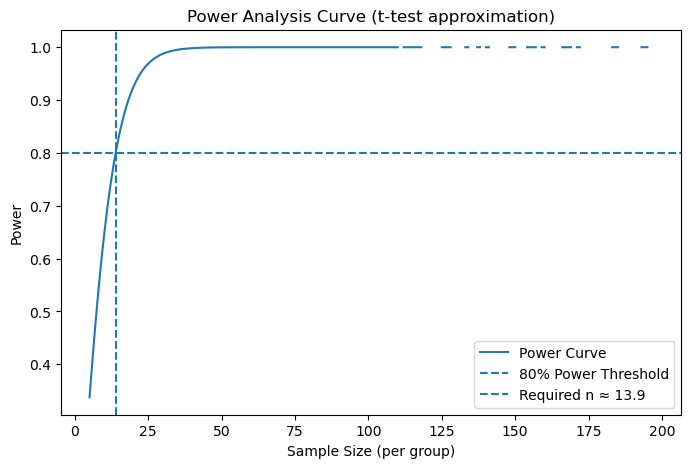

In [69]:
sample_sizes = np.arange(5, 200)

powers = [
    analysis.power(effect_size=d_proxy, nobs1=n, alpha=0.05, ratio=1.0)
    for n in sample_sizes
]

plt.figure(figsize=(8,5))
plt.plot(sample_sizes, powers, label="Power Curve")
plt.axhline(0.80, linestyle="--", label="80% Power Threshold")
plt.axvline(required_n, linestyle="--", label=f"Required n ≈ {required_n:.1f}")

plt.xlabel("Sample Size (per group)")
plt.ylabel("Power")
plt.title("Power Analysis Curve (t-test approximation)")
plt.legend()
plt.show()

Interpretation:
Since the data did not satisfy normality assumptions, the main group comparison was conducted using the Mann-Whitney U test.
However, because standard closed-form power analysis is limited for non-parametric tests, an approximate power analysis was performed
using a t-test-based framework with Cohen’s d as a proxy effect size.